<a href="https://colab.research.google.com/github/Akhila-010/GenAI_Tasks/blob/main/Worldcloud_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nltk wordcloud

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from wordcloud import WordCloud

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from tensorflow.keras.datasets import imdb

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=5000)

# Get word index
word_index = imdb.get_word_index()

# Reverse dictionary
reverse_word_index = dict((value, key) for (key, value) in word_index.items())

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i-3, '?') for i in encoded_review])

X_train_text = [decode_review(review) for review in X_train]
X_test_text = [decode_review(review) for review in X_test]

In [ ]:
stop_words = set(stopwords.words('english'))
ps = PorterStemmer()

def preprocess(text):
    text = text.lower()
    text = re.sub('[^a-z]', ' ', text)
    words = text.split()

    words = [ps.stem(word) for word in words if word not in stop_words]

    return ' '.join(words)

X_train_clean = [preprocess(text) for text in X_train_text]
X_test_clean = [preprocess(text) for text in X_test_text]

In [ ]:
bow = CountVectorizer(max_features=5000)

X_train_bow = bow.fit_transform(X_train_clean)
X_test_bow = bow.transform(X_test_clean)

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_test_tfidf = tfidf.transform(X_test_clean)

In [ ]:
lr = LogisticRegression()

lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

In [ ]:
nb = MultinomialNB()

nb.fit(X_train_bow, y_train)

y_pred_nb = nb.predict(X_test_bow)

In [ ]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.87612
              precision    recall  f1-score   support

           0       0.88      0.87      0.88     12500
           1       0.87      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



In [ ]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8366
              precision    recall  f1-score   support

           0       0.82      0.86      0.84     12500
           1       0.85      0.82      0.83     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



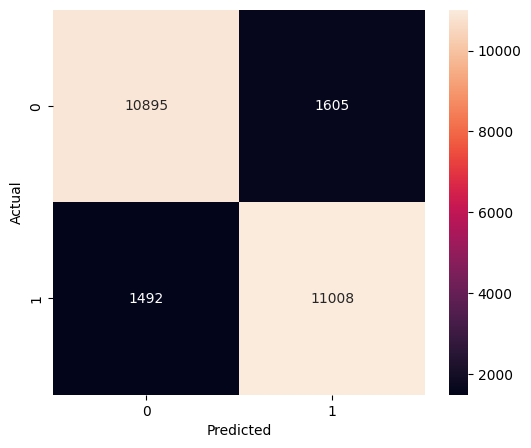

In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

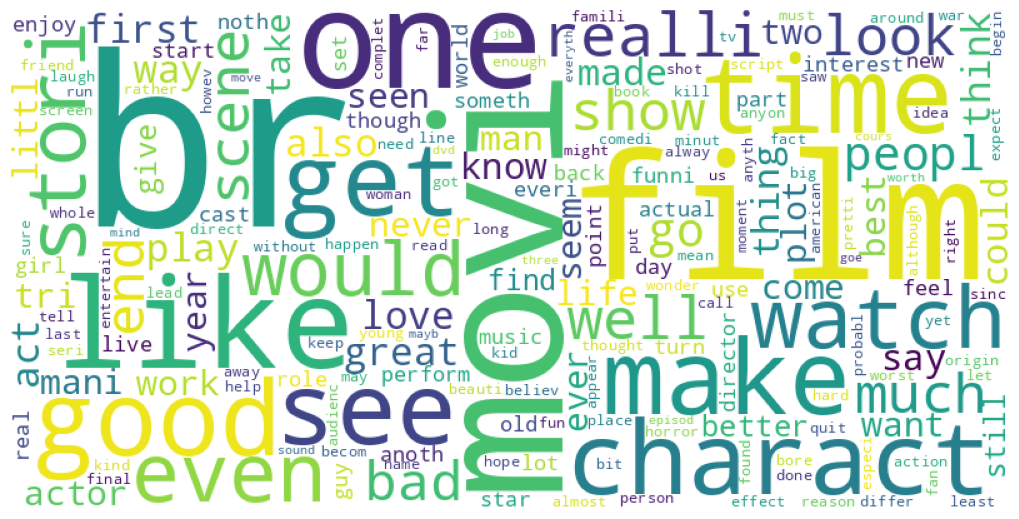

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# Combine all processed reviews into a single string
all_processed_reviews = X_train_clean + X_test_clean
all_words = ' '.join(all_processed_reviews)

# Count word frequencies
word_frequencies = Counter(all_words.split())

# Generate a word cloud
wordcloud = WordCloud(width = 800, height = 400,
                background_color ='white',
                min_font_size = 10).generate_from_frequencies(word_frequencies)

# Display the word cloud
plt.figure(figsize = (10, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

plt.show()